In [1]:
#Quick sanity check

print("all is well")

all is well


## RAG BASICS

In [2]:
# Read the .env file and load the environment variables
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
# Using Langchain's Google Generative AI Embeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings

#Initializing the embedding model with the specific embedding model "models/gemini-embedding-001"
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# Convert a smaple query to numerical vector representation using the embedding model
vector = embeddings.embed_query("What is RAG?")

#Display the first 5 dimensions of the resulting embedding vector
print(vector[:5])

[-0.0050992095, 0.012719812, -0.015219515, -0.056661323, -0.010068115]


## 1. Data Ingestion

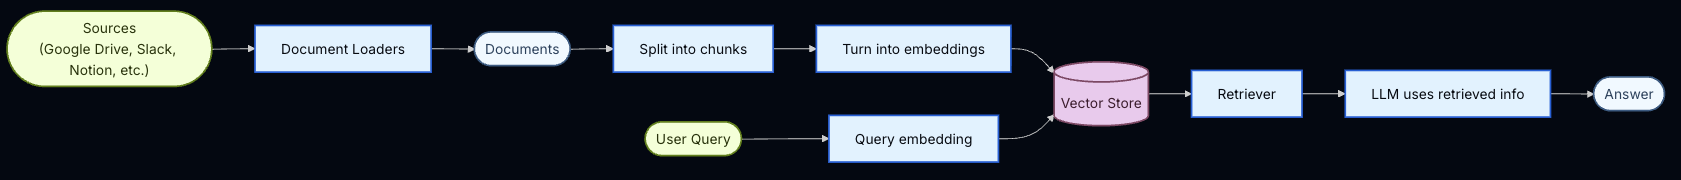

In [5]:
# Import PDF leaders to read and process PDF documents page by page
from langchain_community.document_loaders import PyPDFLoader
import os

# Import text splitter to break large documents into smaller chunks for better processing and embedding
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [6]:
#Verify the current working directory
os.getcwd()

'/Users/2099070/Documents/Cognizant/12 May - RAG Basics'

In [7]:
# Build the full file path to the PDF document
file_path=os.path.join(os.getcwd(),"2511.09030v1.pdf")

In [8]:
file_path

'/Users/2099070/Documents/Cognizant/12 May - RAG Basics/2511.09030v1.pdf'

In [9]:
# Create a PDF loader and load the document (each page becomes a separate Document object)
loader = PyPDFLoader(file_path)
document = loader.load()
#PREVIEW THE 11TH PAGE (INDEX 10) TO INSPECT THE LOADED CONTENT
document[10]

Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:4177c2c)', 'creationdate': '', 'author': 'Elliot Meyerson; Giuseppe Paolo; Roberto Dailey; Hormoz Shahrzad; Olivier Francon; Conor F. Hayes; Xin Qiu; Babak Hodjat; Risto Miikkulainen', 'doi': 'https://doi.org/10.48550/arXiv.2511.09030', 'license': 'http://creativecommons.org/licenses/by/4.0/', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) kpathsea version 6.4.1', 'title': 'Solving a Million-Step LLM Task with Zero Errors', 'trapped': '/False', 'arxivid': 'https://arxiv.org/abs/2511.09030v1', 'source': '/Users/2099070/Documents/Cognizant/12 May - RAG Basics/2511.09030v1.pdf', 'total_pages': 29, 'page': 10, 'page_label': '11'}, page_content='Solving a Million-Step LLM Task with Zero Errors\nFigure 7:A snapshot of the million-step problem-solving process.The dots in the background represent the steps,\nordered in rows from top to bottom. At step 479,806, MAKER is near t

In [10]:
# Configure the text splitter to break documents into chunks of 1000 characters
# with 200-character overlap to preserve context across chunk boundaries
# Note: chunk_size and chunk_overlap are experimental — no deterministic best values yet
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, 
    chunk_overlap=200, 
    length_function=len
    )

In [11]:
# Split the loaded PDF into smaller, overlapping chunks
docs = text_splitter.split_documents(document)

In [12]:
docs

[Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:4177c2c)', 'creationdate': '', 'author': 'Elliot Meyerson; Giuseppe Paolo; Roberto Dailey; Hormoz Shahrzad; Olivier Francon; Conor F. Hayes; Xin Qiu; Babak Hodjat; Risto Miikkulainen', 'doi': 'https://doi.org/10.48550/arXiv.2511.09030', 'license': 'http://creativecommons.org/licenses/by/4.0/', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) kpathsea version 6.4.1', 'title': 'Solving a Million-Step LLM Task with Zero Errors', 'trapped': '/False', 'arxivid': 'https://arxiv.org/abs/2511.09030v1', 'source': '/Users/2099070/Documents/Cognizant/12 May - RAG Basics/2511.09030v1.pdf', 'total_pages': 29, 'page': 0, 'page_label': '1'}, page_content='SOLVING AMILLION-STEPLLM TASK WITHZEROERRORS\nElliot Meyerson∗\nCognizant AI Lab\nGiuseppe Paolo\nCognizant AI Lab\nRoberto Dailey\nCognizant AI Lab\nHormoz Shahrzad\nUT Austin & Cognizant AI Lab\nOlivier Francon\nCognizant AI Lab\n

In [13]:
#Compare:number of original pages vs. number of chunks after splitting
len(document), len(docs)

(29, 121)

In [ ]:
# Display the raw text content of the first page
document[0].page_content